In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
img_escura = cv2.imread('./data/teste_escuridao.png')
img_clara = cv2.imread('./data/teste_exposicao_alta.png')

img_escura_rgb = cv2.cvtColor(img_escura, cv2.COLOR_BGR2RGB)
img_clara_rgb = cv2.cvtColor(img_clara, cv2.COLOR_BGR2RGB)


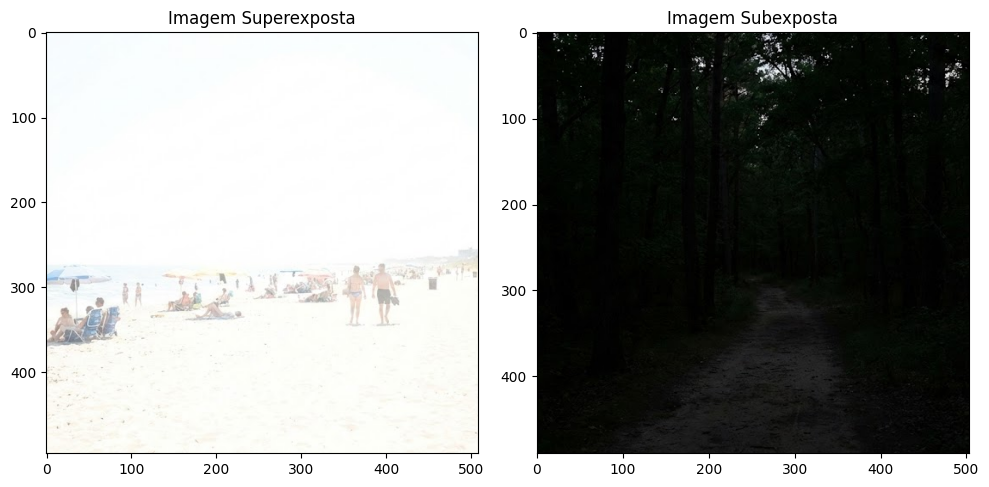

In [3]:
fig, axes = plt.subplots(1,2,figsize= (10,8))

axes[0].imshow(img_clara_rgb)
axes[1].imshow(img_escura_rgb)
axes[0].set_title("Imagem Superexposta")
axes[1].set_title("Imagem Subexposta")
plt.tight_layout()

In [4]:
type(img_clara_rgb),type(img_escura_rgb) 

(numpy.ndarray, numpy.ndarray)

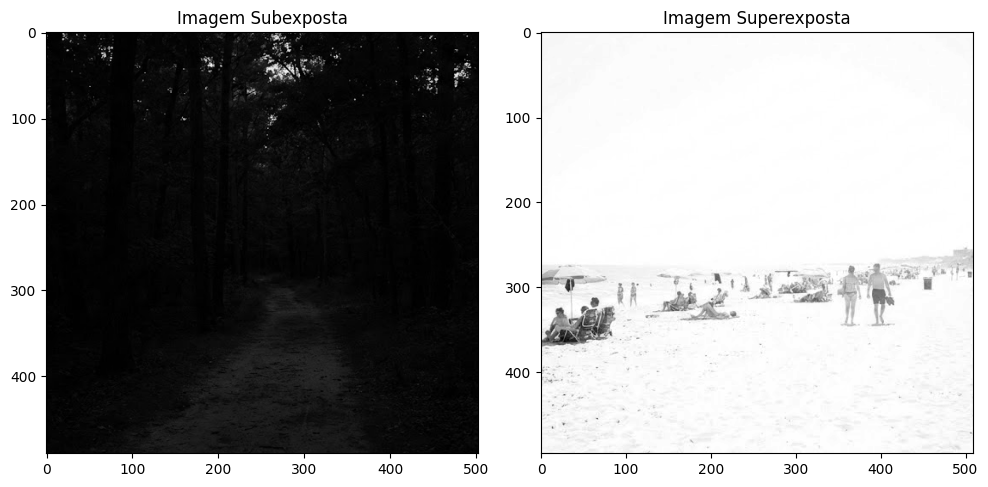

In [5]:
img_escuridao_gray = cv2.cvtColor(img_escura_rgb, cv2.COLOR_RGB2GRAY)
img_clara_gray = cv2.cvtColor(img_clara_rgb, cv2.COLOR_RGB2GRAY)

fig, axes = plt.subplots(1,2,figsize= (10,8))

axes[0].imshow(img_escuridao_gray,cmap='gray')
axes[1].imshow(img_clara_gray,cmap='gray')
axes[1].set_title("Imagem Superexposta")
axes[0].set_title("Imagem Subexposta")
plt.tight_layout()

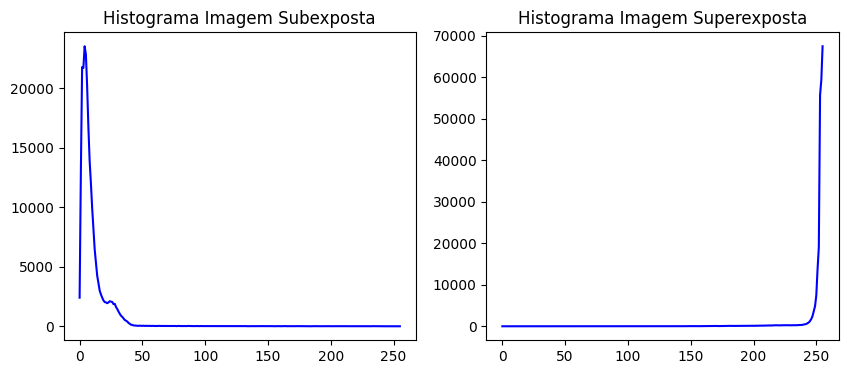

In [6]:
# computing the histogram of the blue channel of the image
hist_escuro = cv2.calcHist([img_escuridao_gray],[0],None,[256],[0,256])
hist_claro = cv2.calcHist([img_clara_gray],[0],None,[256],[0,256])
# plot the above computed histogram

fig, axes = plt.subplots(1,2,figsize=(10,4))
axes[0].plot(hist_escuro, color='b')
axes[1].plot(hist_claro, color='b')

axes[1].set_title("Histograma Imagem Superexposta")
axes[0].set_title("Histograma Imagem Subexposta")
plt.show()

In [7]:
hist_escuro

array([[2.4010e+03],
       [1.2946e+04],
       [2.1768e+04],
       [2.1693e+04],
       [2.3514e+04],
       [2.2836e+04],
       [2.0128e+04],
       [1.6710e+04],
       [1.3864e+04],
       [1.2010e+04],
       [9.9270e+03],
       [8.1650e+03],
       [6.4590e+03],
       [5.3330e+03],
       [4.2520e+03],
       [3.6360e+03],
       [2.9930e+03],
       [2.6680e+03],
       [2.4050e+03],
       [2.1680e+03],
       [2.0330e+03],
       [2.0020e+03],
       [1.9390e+03],
       [2.0020e+03],
       [2.1020e+03],
       [2.0730e+03],
       [2.0380e+03],
       [1.8590e+03],
       [1.8850e+03],
       [1.6170e+03],
       [1.4460e+03],
       [1.2330e+03],
       [1.0440e+03],
       [8.8700e+02],
       [7.8600e+02],
       [6.5300e+02],
       [5.2600e+02],
       [4.6700e+02],
       [3.9000e+02],
       [2.7500e+02],
       [2.0900e+02],
       [1.2600e+02],
       [1.0900e+02],
       [7.2000e+01],
       [6.0000e+01],
       [5.1000e+01],
       [4.4000e+01],
       [3.900

In [8]:
img_escuridao_gray_mean = np.mean(img_escuridao_gray)
img_clara_gray_mean = np.mean(img_clara_gray)

img_clara_gray_mean, img_escuridao_gray_mean

(250.8402821788453, 10.044699152026617)

In [9]:
img_clara_rgb_mean = np.mean(img_clara_rgb)
img_escura_rgb_mean = np.mean(img_escura_rgb)

img_clara_rgb_mean,img_escura_rgb_mean

(250.35207263873926, 9.168354498857196)

In [10]:
def ajustar_gama(img, gamma=1.0):
    invGamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** invGamma) * 255 
        for i in np.arange(0, 256)]).astype("uint8")

    return cv2.LUT(img, table)

In [11]:
limite_superior = 250
limite_inferior = 10

def diagnostico(img):
    img_mean = np.mean(img)

    if img_mean > limite_superior:
        img_clara_melhorada = ajustar_gama(img, 0.08)
        return img_clara_melhorada
    if img_mean < limite_inferior:
        img_escura_melhorada = ajustar_gama(img, 2)
        return img_escura_melhorada


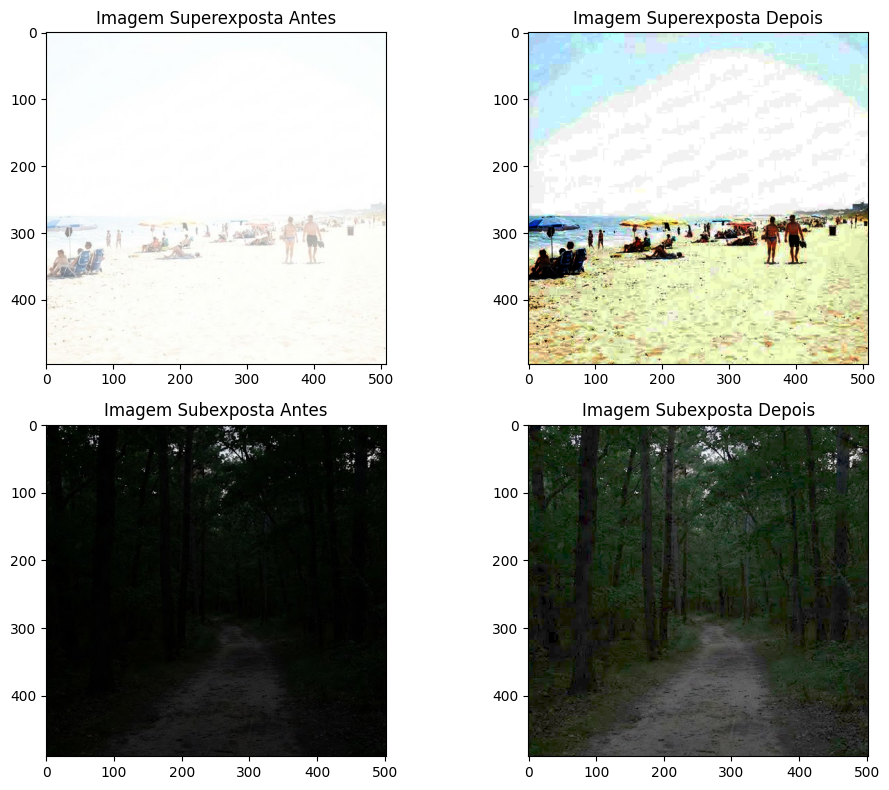

In [12]:
img_melorada_escura = diagnostico(img_escura_rgb)
img_melorada_clara = diagnostico(img_clara_rgb)


fig, axes = plt.subplots(2,2,figsize= (10,8))

axes[0,0].imshow(img_clara_rgb)
axes[0,0].set_title("Imagem Superexposta Antes")

axes[0,1].imshow(img_melorada_clara)
axes[0,1].set_title("Imagem Superexposta Depois")

axes[1,0].imshow(img_escura_rgb)
axes[1,0].set_title("Imagem Subexposta Antes")

axes[1,1].imshow(img_melorada_escura)
axes[1,1].set_title("Imagem Subexposta Depois")

plt.tight_layout()